# Week 5 Residual connections and layer normalization

For this weeks assignment I will use IMDB dataset imported directly from keras. The dataset contains a huge amount of movie reviews labeled as positive or negative. Teacher has provided code for a binary classifier model containing token and positional embedding layers with multi-head attention layer. I will use that as a base and expand it by adding components.

Components I will add:
- Fully connected feed forward network
- Two residual connections (bypassing the attention layer and the feed forward network)
- Two normalization layers (directly after the two residual connections)
- Global average pooling 1D layer (connects the output of the encoder block to the final output layer)
- Output layer for binary classification (sigmoid activation function)

In [57]:
# Importing necessary libraries and the dataset
import keras
from keras.datasets import imdb
from keras.layers import Layer, Embedding
from keras.layers import Input, Dense, GlobalAveragePooling1D, Dropout
from keras.layers import MultiHeadAttention, Add, LayerNormalization  # Add and LayerNormalization for residual connections
from keras.models import Model
import matplotlib.pyplot as plt
from keras.src.callbacks import EarlyStopping
from keras.src.callbacks import ReduceLROnPlateau

max_features = 10000  # vocabulary size
max_len = 250         # words per sample

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad all samples to the same length so they can be batched together
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len, padding='post')

The IMDB dataset is preprocessed and ready to be used for training. The reviews are tokenized and converted to sequences of integers, where each integer represents a specific word in the vocabulary. The sequences are then padded to ensure that all samples have the same length, which is necessary for training the model.

In [58]:
word_to_index = imdb.get_word_index()
index_to_word = dict((value, key) for (key, value) in word_to_index.items())

example_review = " ".join(index_to_word.get(i-3, "?") for i in x_train[12])
print(example_review)

? i love cheesy horror flicks i don't care if the acting is sub par or whether the monsters look corny i liked this movie except for the ? feeling all the way from the beginning of the film to the very end look i don't need a 10 page ? or a sign with big letters explaining a plot to me but dark floors takes the what is this movie about thing to a whole new annoying level what is this movie about br br this isn't exceptionally scary or thrilling but if you have an hour and a half to kill and or you want to end up feeling frustrated and confused rent this winner ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?


## Positional embedding layer

The code below defines a custom Keras layer called `TokenAndPositionEmbedding`. This layer combines token embeddings and positional embeddings to create a rich representation of the input sequences. The token embedding converts each integer token ID into a dense vector representation, while the positional embedding adds information about the position of each token in the sequence. This is crucial for models like Transformers, which do not have an inherent sense of order in the input data. By adding the token and positional embeddings together, the model can learn both the meaning of the tokens and their positions in the sequence, allowing it to capture complex relationships between words in a review.

In [59]:
class TokenAndPositionEmbedding(Layer):
    def __init__(self, seq_len, vocab_size, emb_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)
        self.pos_emb = Embedding(input_dim=seq_len, output_dim=emb_dim)

    def call(self, x_input):
        seq_len = keras.ops.shape(x_input)[-1]
        positions = keras.ops.arange(start=0, stop=seq_len, step=1)
        positions = self.pos_emb(positions)
        x_input = self.token_emb(x_input)
        return x_input + positions

## Transformer Encoder Block Architecture

The model below implements a simplified **Transformer encoder block** that implements residual connections and layer normalization.

The architecture consists of the following components:
1. **Input Layer**: Accepts sequences of token IDs. These IDs are the movie reviews represented as sequences of integers.
2. **Token and Positional Embedding**: Each token ID is converted into a dense embedding vector, and a positional embedding is added to provide information about the position of each token in the sequence. The dense embedding vectors capture the semantic meaning of the tokens, while the positional embeddings allow the model to understand the order of the tokens.

At this point the outputs of the token and embedding layer are saved in a variable called `residual_1` to be used later for the first residual connection. The architecture then continues with the following components:

3. **Multi-Head Attention**: This layer takes in (query, value) pairs and computes attention scores to allow the model to focus on different parts of the input sequence when processing each token. In this case, we use self-attention by passing the same input for both query and value.

After the multi-head attention layer, we add the output of the attention back to the original input (the "residual" connection) and apply layer normalization to stabilize the activations. This allows the model to learn both the original information and the new information from attention without losing either. Next we save the output of the layer normalization in a variable called `residual_2` to be used later for the second residual connection. Then comes the feedforward network:

4. **Feedforward Network**: This consists of two dense layers. The first dense layer expands the dimensionality to `ff_dim` (64) and applies a ReLU activation function to introduce non-linearity. The second dense layer projects the output back down to `embed_dim` (32) without an activation function, which is critical for the residual connection to work properly. The second layer can not have an activation function because the output must be in the same space as the input to the residual connection. After the feedforward network, we again add the output back to the input of this sub-layer (the second residual connection) and apply layer normalization.
5. **Global Average Pooling 1D**: This layer takes the output of the encoder block and computes the average across the time dimension (the sequence length), resulting in a fixed-size vector that summarizes the information from the entire sequence.
6. **Dropout**: This layer randomly sets a fraction of the input units to 0 during training to prevent overfitting and encourage the model to learn more robust features.
7. **Output Layer**: A dense layer with a sigmoid activation function that outputs a single value between 0 and 1, representing the probability of the review being positive (1) or negative (0).

In [60]:
# Hyperparameters
embed_dim = 32   # dimensionality of each token's embedding vector
num_heads = 2    # number of parallel attention heads in MultiHeadAttention
key_dim   = embed_dim // num_heads  # query/key dimension per head (16)
ff_dim    = 64   # hidden units in the feedforward network (expanded space)

# INPUT
inputs = Input(shape=(max_len,))

# TOKEN + POSITIONAL EMBEDDING
# Each integer token ID is looked up in an embedding table (token embedding),
# and a separate positional embedding is added so the model knows each token's position in the sequence.
x = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs)

# Save x before attention layer for the residual connection
residual_1 = x

# Self-attention: every token position attends to every other position.
# The layer takes (query, value), passing x for both means self-attention.
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)

# Residual connection 1: add the attention output back to the original embedding.
# The model now carries both "what attention learned" and "what was there before".
x = Add()([attention_output, residual_1])

# Layer normalization 1: normalize across the 32 feature dimensions for each
# token position independently, stabilizing the activations after the addition.
# Output shape: (None, 250, 32)
x = LayerNormalization()(x)

# Save x before feedforward network for the second residual connection
residual_2 = x

# First Dense: expand to ff_dim (64) and apply ReLU to introduce non-linearity.
ff = Dense(ff_dim, activation='relu')(x)

# Second Dense: project back down to embed_dim (32).
# CRITICAL: must match embed_dim so that Add()([ff, residual_2]) is valid.
ff = Dense(embed_dim)(ff)

# Residual connection 2: add the feedforward output to the input of this sub-layer.
x = Add()([ff, residual_2])

# Layer normalization 2: same purpose as the first normalization
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)

# Dropout for regularization and to prevent the model from over-relying on any single feature.
x = Dropout(0.5)(x)

# Output layer: a single sigmoid unit for binary classification.
# Values close to 1 → positive review; close to 0 → negative review.
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_7[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 250, 32)   │          0 │ multi_head_atten… │
│                     │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 250, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 250, 32)   │      2,080 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 250, 32)   │          0 │ dense_15[0][0],   │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         33 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 336,577 (1.28 MB)

 Trainable params: 336,577 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Training the model with early stopping and adjusted learning rate
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.7809 - loss: 0.4459 - val_accuracy: 0.8602 - val_loss: 0.3301
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9138 - loss: 0.2238 - val_accuracy: 0.8810 - val_loss: 0.2901
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9417 - loss: 0.1599 - val_accuracy: 0.8772 - val_loss: 0.3010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9607 - loss: 0.1107 - val_accuracy: 0.8706 - val_loss: 0.3902
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9694 - loss: 0.0839 - val_accuracy: 0.8700 - val_loss: 0.4795


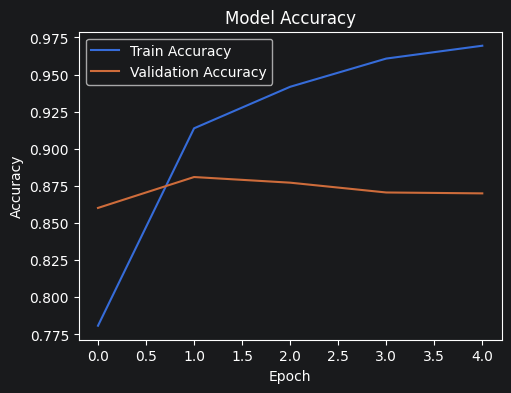

In [62]:
# Plotting training accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [63]:
print(f'Test accuracy = {model.evaluate(x_test, y_test)[1]:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8503 - loss: 0.5237
Test accuracy = 0.8503


## Evaluation

After evaluating the model on the test set, we can see that the test accuracy is around 0.85, which indicates that the model is performing well on unseen data. But I think this dataset might be on the smaller side to fully utilize the capabilities of the transformer architecture. That might be the reason why the model is not performing too much better than a simpler non-transformer model. The architecture is quite complex and might be overkill for this dataset, which would make sense since from the plotted history we can see that the validation history begins a slow decline after the first epoch.